# Assignment 1: Data Exploration

**Main Question:** What does Airbnb data from the past year reveal about broader economic trends in New York City?

**Our three hypotheses:**
- **H1:** Review based booking demand is geographically concentrated in a small number of NYC neighbourhoods, reflecting uneven tourism recovery
- **H2:** NYC's Local Law 18 has fundamentally restructured the 
  short-term rental market — 85% of listings now require 30+ night 
  minimums, compressing genuine short-term supply to just 15%

- **H3:** NYC Airbnb nightly prices rose 9.9% over the analysis period, 
  nearly 3x the general inflation rate, with outer boroughs experiencing 
  the sharpest increases

### Data Availability Note

The assignment asks for one year of Airbnb data. At the time of download, InsideAirbnb's public NYC archive had 11 available snapshots from June 17, 2025 to April 14, 2026. This analysis uses all available snapshots. The 11-month window rather than a full 12 months is a limitation of the public archive, not an intentional exclusion.

---
## Section 1: Setup & Libraries

In [6]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

---
## Section 2: Load the Data

There is 11 monthly snapshots, each saved as a separate file named `listings (1).csv` through `listings (11).csv` and the same for reviews. These files are stored in a `data/` folder.

I used a loop to load all 11 files and stack them together using `pd.concat()`. Each row gets tagged with a `month_num` column so I can track which snapshot it came from.

In [7]:
# Load all 11 months of listings
# Same pd.read_csv() pattern from class, just repeated in a loop

listings_frames = []

for i in range(1, 12):
    path = f'data/listings ({i}).csv'
    df_month = pd.read_csv(path, low_memory=False)
    df_month['month_num'] = i
    listings_frames.append(df_month)

listings_all = pd.concat(listings_frames, ignore_index=True)
print(f'Loaded {len(listings_all):,} listing rows across {listings_all["month_num"].nunique()} months')

Loaded 397,719 listing rows across 11 months


In [8]:
# Load all 11 months of reviews

reviews_frames = []

for i in range(1, 12):
    path = f'data/reviews ({i}).csv'
    chunks = []
    try:
        for chunk in pd.read_csv(path,
                                  chunksize=10000,
                                  on_bad_lines='skip',
                                  quoting=3,
                                  encoding='utf-8',
                                  engine='python'):
            chunks.append(chunk)
    except Exception as e:
        print(f'Error on file {i}: {e}')

    df_rev = pd.concat(chunks, ignore_index=True)
    df_rev['month_num'] = i
    reviews_frames.append(df_rev)

reviews_raw = pd.concat(reviews_frames, ignore_index=True)
print(f'Loaded {len(reviews_raw):,} raw review rows across 11 months')

Loaded 10,893,116 raw review rows across 11 months


In [9]:
# Load neighbourhoods 
neighbourhoods = pd.read_csv('data/neighbourhoods.csv')
print(f'Loaded {len(neighbourhoods)} neighbourhoods')

Loaded 230 neighbourhoods


---
## Section 3: First Look at the Data

Before I clean anything, I use the same tools like — `head()`, `info()`, and `describe()` — to check the shape, column types, missing values, and basic statistics.

In [10]:
print('Listings shape:', listings_all.shape)
print('Reviews shape: ', reviews_raw.shape)

Listings shape: (397719, 20)
Reviews shape:  (10893116, 3)


In [11]:
listings_all.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,month_num
0,2595,Skylit Studio Oasis | Midtown Manhattan Sanctuary,2845,1.462506e+18,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,NaN,30.0,47,2022-06-21,0.24,3,256,0,NaN,1
1,6848,Only 2 stops to Manhattan studio,15991,1.462507e+18,Allen,Brooklyn,Williamsburg,40.70935,-73.95342,Entire home/apt,NaN,30.0,197,2025-11-17,0.97,1,198,4,NaN,1
2,6872,Uptown Sanctuary w/ Private Bath (Month to Month),16104,1.462507e+18,Kae,Manhattan,East Harlem,40.80107,-73.94255,Private room,NaN,30.0,2,2025-10-07,0.04,2,83,1,NaN,1
3,6990,UES Beautiful Blue Room,16800,1.462507e+18,Cynthia,Manhattan,East Harlem,40.78778,-73.94759,Private room,NaN,30.0,251,2026-01-11,1.26,1,214,4,NaN,1
4,7097,"Perfect for Your Parents, With Garden & Patio",17571,1.462507e+18,Jane,Brooklyn,Fort Greene,40.69194,-73.97389,Private room,NaN,2.0,423,2025-09-23,2.16,2,0,26,OSE-STRREG-0000008,1


In [12]:
listings_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397719 entries, 0 to 397718
Data columns (total 20 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              397719 non-null  int64  
 1   name                            397697 non-null  object 
 2   host_id                         397719 non-null  int64  
 3   host_profile_id                 177065 non-null  float64
 4   host_name                       391472 non-null  object 
 5   neighbourhood_group             397719 non-null  object 
 6   neighbourhood                   397719 non-null  object 
 7   latitude                        397719 non-null  float64
 8   longitude                       397719 non-null  float64
 9   room_type                       397719 non-null  object 
 10  price                           170074 non-null  float64
 11  minimum_nights                  397670 non-null  float64
 12  number_of_review

In [13]:
listings_all.describe()

,id,host_id,host_profile_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,month_num
count,3.977190e+05,3.977190e+05,1.770650e+05,397719.000000,397719.000000,170074.000000,397670.000000,397719.000000,274512.000000,397719.000000,397719.000000,397719.000000,397719.000000
mean,4.758788e+17,1.779121e+08,1.466828e+18,40.728511,-73.947355,459.407187,28.496165,27.388976,0.805376,64.338644,162.336962,3.962868,5.980353
std,5.543117e+17,1.971152e+08,1.011557e+16,0.056288,0.055103,3163.862618,29.500599,69.746488,1.854941,210.990795,147.695440,18.713085,3.155307
min,2.539000e+03,1.678000e+03,1.462506e+18,40.500366,-74.251907,3.000000,0.000000,0.000000,0.010000,1.000000,0.000000,0.000000,1.000000
25%,2.164793e+07,1.845837e+07,1.462859e+18,40.688290,-73.983600,90.000000,30.000000,0.000000,0.070000,1.000000,0.000000,0.000000,3.000000
50%,5.122733e+07,9.015435e+07,1.465497e+18,40.726350,-73.955128,156.000000,30.000000,3.000000,0.250000,2.000000,154.000000,0.000000,6.000000
75%,9.867717e+17,3.159057e+08,1.469255e+18,40.762200,-73.928120,270.000000,30.000000,23.000000,0.880000,9.000000,319.000000,1.000000,9.000000
max,1.654399e+18,7.545790e+08,1.649332e+18,40.912017,-73.711822,50184.000000,1124.000000,4310.000000,124.180000,1210.000000,365.000000,1795.000000,11.000000


**What I can see from describe():**

- The `price` column has a mean of $459 but a median of $156. This is the right skew, a small number of very expensive listings are pulling the mean up. The median is a much better representation of what a typical listing actually costs, so I will use **median** throughout this analysis.

- A lot of rows have no price value. Listings with missing prices may be inactive, unlisted, or unavailable.

- The `minimum_nights` median is 30, meaning half of all listings require at least a 30 night stay. 

---
## Section 4: Data Cleaning

I used five cleaning steps. Each one has a clear reason behind it.

### 4.1 - Deduplicate Reviews

Each monthly `reviews.csv` file from InsideAirbnb contains the full review history for every listing up to that snapshot date and not just new reviews for that month. Because I loaded 11 files, the same review can appear up to 11 times in our data.

First we confirm this is happening, then fix it by keeping only unique `listing_id + date` combinations.

I considered using the IQR method from Class 1 to remove price outliers. However, I chose a domain knowledge approach instead because it produces a more defensible and interpretable threshold for a business audience. The reasoning is documented in Section 4.4.

In [14]:
# Convert IDs to string so merging works consistently
reviews_raw['listing_id'] = reviews_raw['listing_id'].astype(str)
listings_all['id'] = listings_all['id'].astype(str)

# Check the duplication problem on a sample listing
sample = reviews_raw[reviews_raw['listing_id'] == '2595']
print(f'Total rows for listing 2595:  {len(sample)}')
print(f'Unique review dates:          {sample["date"].nunique()}')
print(f'Duplication factor:           {len(sample)/sample["date"].nunique():.1f}x')

Total rows for listing 2595:  427
Unique review dates:          49
Duplication factor:           8.7x


In [15]:
# Fix: keep only unique listing_id + date combinations
# This removes the inflation caused by loading 11 files with overlapping review history

reviews_clean = reviews_raw.drop_duplicates(subset=['listing_id', 'date'])

print(f'Before deduplication: {len(reviews_raw):,}')
print(f'After deduplication:  {len(reviews_clean):,}')
print(f'Reduction factor:     {len(reviews_raw)/len(reviews_clean):.1f}x')

Before deduplication: 10,893,116
After deduplication:  1,110,685
Reduction factor:     9.8x


### 4.2 Filter Reviews to the Analysis Period

Even after deduplication, `reviews_clean` still contains historical reviews going back years. Since this assignment is about the past year's economic trends, I filter to only reviews within our analysis window: April 14, 2025 to April 14, 2026.

In [16]:
# Filter reviews to the analysis period
# Using pd.to_datetime() to convert the date column to same as class

reviews_clean['date'] = pd.to_datetime(reviews_clean['date'], errors='coerce')

reviews_clean = reviews_clean[
    (reviews_clean['date'] >= '2025-04-14') &
    (reviews_clean['date'] <= '2026-04-14')
].copy()

print(f'Reviews in analysis period: {len(reviews_clean):,}')
print(f'Date range: {reviews_clean["date"].min().date()} to {reviews_clean["date"].max().date()}')

Reviews in analysis period: 142,923
Date range: 2025-04-14 to 2026-04-14


### 4.3 Split Listings into Two Datasets

Missing prices only matter when we are doing price analysis. For host type and neighbourhood analysis, I still want to include all listings which includes inactive ones that have no price.

So I keep two separate datasets:
- `listings_all` — all rows, used for neighbourhood and host analysis
- `listings_price` — latest snapshot only, valid prices only, used only for price analysis

In [17]:
# listings_all: all rows kept — for neighbourhood and host analysis
print(f'listings_all: {listings_all.shape}')
print(f'Unique listings: {listings_all["id"].nunique():,}')
print(f'\nMonths in listings_all: {sorted(listings_all["month_num"].unique())}')
print(f'\nPrice missing: {listings_all["price"].isna().mean()*100:.1f}% of rows')
print('Listings with missing prices may be inactive or unavailable.')
print('This may reflect supply pressure from regulation but should be interpreted cautiously.')

listings_all: (397719, 20)
Unique listings: 43,037

Months in listings_all: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Price missing: 57.2% of rows
Listings with missing prices may be inactive or unavailable.
This may reflect supply pressure from regulation but should be interpreted cautiously.


In [18]:
# listings_price: latest snapshot only, valid prices, for price analysis
# Using latest snapshot so H2 and H3 look at the same point in time

latest_month = listings_all['month_num'].max()
listings_price = listings_all[
    listings_all['month_num'] == latest_month
].dropna(subset=['price']).copy()

print(f'Latest month: {latest_month}')
print(f'listings_price shape: {listings_price.shape}')

Latest month: 11
listings_price shape: (20693, 20)


### 4.4 Remove Price Outliers

The raw data has prices as high as $50,184 per night, these are almost certainly errors or placeholder values. I remove them using a domain knowledge cap of $1,500 per night, which reflects a realistic ceiling for standard NYC short term rentals.

I validate this by checking the 99th percentile to confirm our cap is reasonable. I considered using the IQR rule but the domain knowledge cap is more defensible here because it uses real market understanding rather than a mechanical formula.

In [21]:
p99 = listings_price['price'].quantile(0.99)
print(f'99th percentile price: ${p99:.0f}')
print(f'Listings over $1,500:  {(listings_price["price"] > 1500).sum():,}')

listings_price = listings_price[
    (listings_price['price'] > 0) &
    (listings_price['price'] <= 1500)
].copy()

print(f'\nAfter removing outliers: {len(listings_price):,} rows')
print(f'Price range: ${listings_price["price"].min():.0f} to ${listings_price["price"].max():.0f}')
print(f'Median: ${listings_price["price"].median():.0f} | Mean: ${listings_price["price"].mean():.0f}')

99th percentile price: $1080
Listings over $1,500:  0

After removing outliers: 20,467 rows
Price range: $4 to $1499
Median: $166 | Mean: $223


### 4.5 Create Listing Snapshot and Enrich Reviews

I use the latest monthly snapshot for H2 (host analysis) and H3 (pricing) since it gives the most current view of the market.

So for H1 I build a `listing_lookup` table that takes the last known record for each listing across all 11 months. This captures listings that active during the analysis period even if they disappeared later.

In [23]:
# Latest snapshot for H2 and H3
listings_snapshot = listings_all[
    listings_all['month_num'] == latest_month
].copy()

print(f'Snapshot month: {latest_month}')
print(f'Snapshot size: {len(listings_snapshot):,} listings')
print(f'Boroughs: {listings_snapshot["neighbourhood_group"].unique()}')

Snapshot month: 11
Snapshot size: 35,036 listings
Boroughs: ['Brooklyn' 'Manhattan' 'Queens' 'Bronx' 'Staten Island']


In [24]:
# Listing lookup for H1: captures all listings active during the year
listing_lookup = (
    listings_all
    .sort_values('month_num')
    .drop_duplicates(subset=['id'], keep='last')
    [['id', 'neighbourhood', 'neighbourhood_group']]
)

print(f'Listing lookup size: {len(listing_lookup):,} unique listings')

Listing lookup size: 43,037 unique listings


In [25]:
# Set indexes and join: following the starter notebook pattern exactly
listings_snapshot_indexed = listings_snapshot.set_index('id')
reviews_indexed = reviews_clean.copy()
reviews_indexed.index = reviews_indexed['listing_id']

merged = listings_snapshot_indexed.join(reviews_indexed, how='inner',
                                        lsuffix='_list', rsuffix='_review')
print(f'Merged shape: {merged.shape}')
merged.head()

Merged shape: (130763, 22)


,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,month_num_list,listing_id,date,month_num_review
id,,,,,,,,,,,,,,,,,,,,,
6848,Only 2 stops to Manhattan studio,15991,1.462507e+18,Allen,Brooklyn,Williamsburg,40.70935,-73.95342,Entire home/apt,117.0,...,2025-11-17,0.96,1,138,3,NaN,11,6848,2025-06-09,1
6848,Only 2 stops to Manhattan studio,15991,1.462507e+18,Allen,Brooklyn,Williamsburg,40.70935,-73.95342,Entire home/apt,117.0,...,2025-11-17,0.96,1,138,3,NaN,11,6848,2025-10-10,1
6848,Only 2 stops to Manhattan studio,15991,1.462507e+18,Allen,Brooklyn,Williamsburg,40.70935,-73.95342,Entire home/apt,117.0,...,2025-11-17,0.96,1,138,3,NaN,11,6848,2025-11-17,1
6872,Uptown Sanctuary w/ Private Bath (Month to Month),16104,1.462507e+18,Kae,Manhattan,East Harlem,40.80107,-73.94255,Private room,67.0,...,2025-10-07,0.04,2,83,1,NaN,11,6872,2025-10-07,1
6990,UES Beautiful Blue Room,16800,1.462507e+18,Cynthia,Manhattan,East Harlem,40.78778,-73.94759,Private room,77.0,...,2026-01-11,1.25,1,273,3,NaN,11,6990,2025-05-27,1


In [26]:
# Create reviews_enriched for H1 groupby analysis

reviews_enriched = reviews_clean.merge(
    listing_lookup,
    left_on='listing_id',
    right_on='id',
    how='inner'
)
print(f'Reviews with neighbourhood info: {len(reviews_enriched):,}')
print(reviews_enriched[['listing_id', 'date', 'neighbourhood', 'neighbourhood_group']].head())

Reviews with neighbourhood info: 142,923
  listing_id       date neighbourhood neighbourhood_group
0       6848 2025-06-09  Williamsburg            Brooklyn
1       6848 2025-10-10  Williamsburg            Brooklyn
2       6848 2025-11-17  Williamsburg            Brooklyn
3       6872 2025-10-07   East Harlem           Manhattan
4       6990 2025-05-27   East Harlem           Manhattan


---
## Section 5: Hypothesis 1: Review Based Demand is Geographically Concentrated

**Hypothesis:** Review based booking demand is geographically concentrated in a small number of NYC neighbourhoods, reflecting uneven tourism recovery across the city.

In [27]:
# Review count by borough
borough_demand = (
    reviews_enriched
    .groupby('neighbourhood_group')['listing_id']
    .count()
    .reset_index()
    .rename(columns={'listing_id': 'review_count'})
    .sort_values('review_count', ascending=False)
)

total = borough_demand['review_count'].sum()
borough_demand['pct_share'] = (borough_demand['review_count'] / total * 100).round(1)
print(borough_demand)
print(f'\nTotal reviews in analysis period: {total:,}')

  neighbourhood_group  review_count  pct_share
2           Manhattan         60340       42.2
1            Brooklyn         51536       36.1
3              Queens         25975       18.2
0               Bronx          3790        2.7
4       Staten Island          1282        0.9

Total reviews in analysis period: 142,923


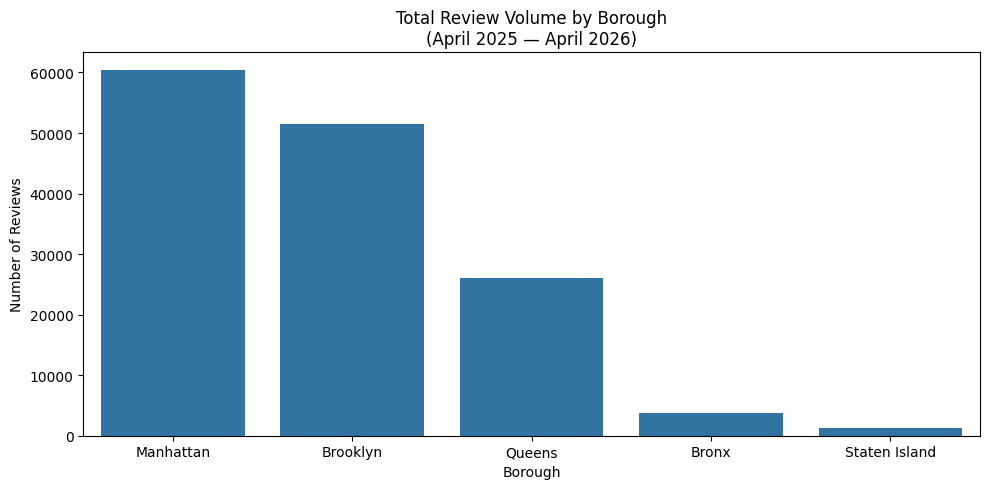

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(data=borough_demand, x='neighbourhood_group', y='review_count')
plt.title('Total Review Volume by Borough\n(April 2025 — April 2026)')
plt.xlabel('Borough')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

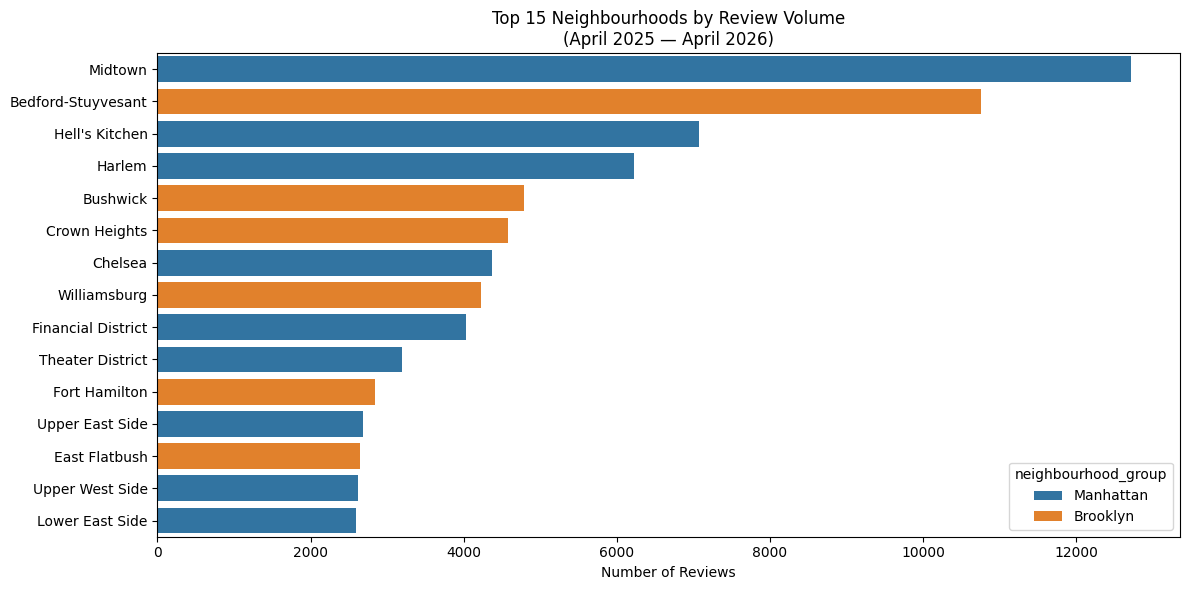

     neighbourhood neighbourhood_group  review_count
           Midtown           Manhattan         12720
Bedford-Stuyvesant            Brooklyn         10762
    Hell's Kitchen           Manhattan          7071
            Harlem           Manhattan          6229
          Bushwick            Brooklyn          4784
     Crown Heights            Brooklyn          4577
           Chelsea           Manhattan          4366
      Williamsburg            Brooklyn          4230
Financial District           Manhattan          4026
  Theater District           Manhattan          3194
     Fort Hamilton            Brooklyn          2839
   Upper East Side           Manhattan          2691
     East Flatbush            Brooklyn          2643
   Upper West Side           Manhattan          2615
   Lower East Side           Manhattan          2588


In [29]:
# Top 15 neighbourhoods
neighbourhood_demand = (
    reviews_enriched
    .groupby(['neighbourhood_group', 'neighbourhood'])['listing_id']
    .count()
    .reset_index()
    .rename(columns={'listing_id': 'review_count'})
    .sort_values('review_count', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=neighbourhood_demand, x='review_count', y='neighbourhood',
            hue='neighbourhood_group')
plt.title('Top 15 Neighbourhoods by Review Volume\n(April 2025 — April 2026)')
plt.xlabel('Number of Reviews')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(neighbourhood_demand[['neighbourhood','neighbourhood_group','review_count']].to_string(index=False))

In [31]:
# Key H1 numbers — using f-strings from Class 1
bk_mn = borough_demand[borough_demand['neighbourhood_group'].isin(['Brooklyn','Manhattan'])]['review_count'].sum()
bx_si = borough_demand[borough_demand['neighbourhood_group'].isin(['Bronx','Staten Island'])]['review_count'].sum()
print(f'Brooklyn + Manhattan share: {bk_mn/total*100:.1f}% of all reviews')
print(f'Bronx + Staten Island share: {bx_si/total*100:.1f}% of all reviews')
print(f'Top neighbourhood: {neighbourhood_demand.iloc[0]["neighbourhood"]} ({neighbourhood_demand.iloc[0]["neighbourhood_group"]})')

Brooklyn + Manhattan share: 78.3% of all reviews
Bronx + Staten Island share: 3.5% of all reviews
Top neighbourhood: Midtown (Manhattan)


**H1 Finding:**

Brooklyn and Manhattan together account for the large majority of all review activity in the analysis period. The Bronx and Staten Island combined make up a very small share despite having large residential populations.

---
## Section 6: Hypothesis 2 — NYC's Local Law 18 Has Fundamentally  
Restructured the Short-Term Rental Market

**Hypothesis:** The enforcement of NYC Local Law 18 in September 2023 
has permanently changed the structure of the short-term rental market. 

**Why this matters economically:**

Before Local Law 18, a host could list their entire apartment for 
1-2 night stays while they were away. After enforcement, hosts must 
be physically present during all guest stays.

This created two possible responses for hosts:
1. Exit the platform entirely
2. Pivot to 30+ night minimums and stay listed

The data shows most hosts chose option 2. That decision has two 
direct economic consequences:

- It dramatically reduces the supply of genuine short-term 
  accommodation available to tourists and visitors
- It moves those listings into direct competition with NYC's 
  long-term rental market, reducing residential housing availability 
  for ordinary New Yorkers

In [47]:
# Track the share of listings requiring 30+ night minimums over time
# This is our Local Law 18 compliance signal
# A growing share = hosts pivoting to medium-term rather than exiting

min_nights_trend = (
    listings_all
    .groupby('month_num')
    .apply(lambda g: (g['minimum_nights'] >= 30).mean() * 100)
    .reset_index()
    .rename(columns={0: 'pct_30plus'})
)

print('% of listings requiring 30+ night minimum by month:')
print(min_nights_trend.to_string(index=False))

% of listings requiring 30+ night minimum by month:
 month_num  pct_30plus
         1   85.098093
         2   85.352478
         3   85.527150
         4   85.338211
         5   85.583340
         6   85.557521
         7   85.550641
         8   85.879763
         9   85.879082
        10   84.729981
        11   84.181984


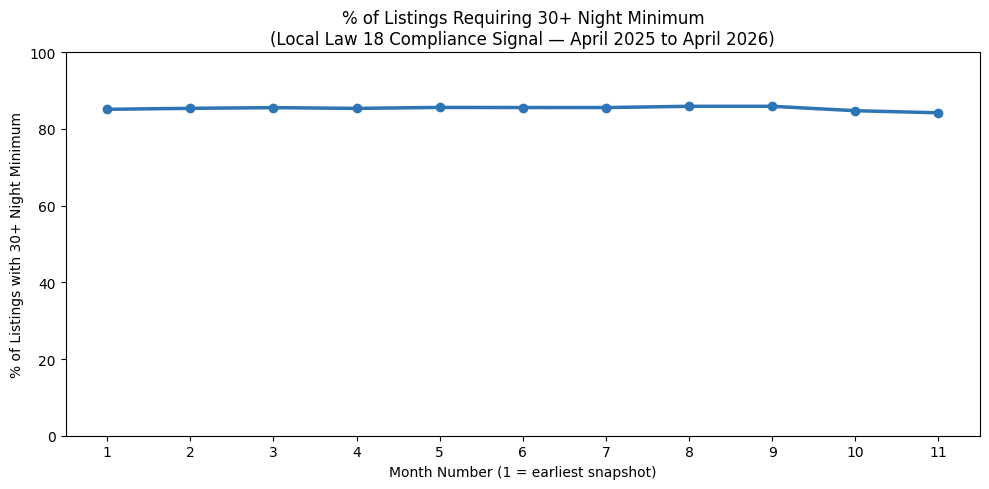

In [48]:
# Visualize the trend over time
plt.figure(figsize=(10, 5))
plt.plot(min_nights_trend['month_num'], min_nights_trend['pct_30plus'],
         marker='o', linewidth=2.5, color='#2E75B6')
plt.title('% of Listings Requiring 30+ Night Minimum\n(Local Law 18 Compliance Signal — April 2025 to April 2026)')
plt.xlabel('Month Number (1 = earliest snapshot)')
plt.ylabel('% of Listings with 30+ Night Minimum')
plt.xticks(min_nights_trend['month_num'])
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

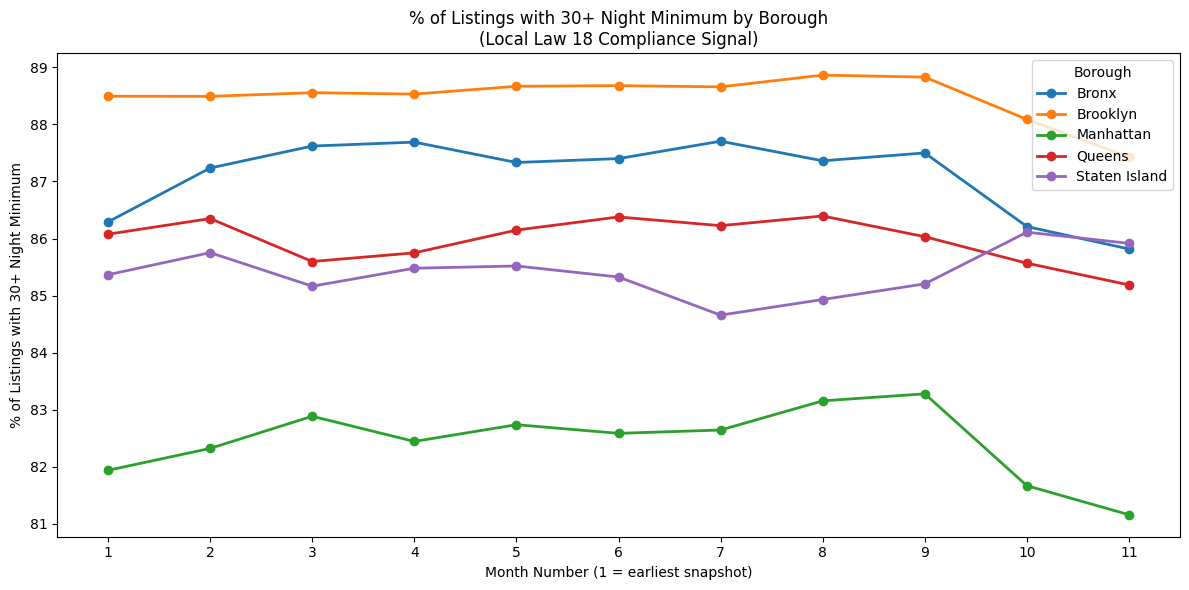

In [49]:
# Break it down by borough — is the regulatory response even across NYC?
min_nights_borough = (
    listings_all
    .groupby(['month_num', 'neighbourhood_group'])
    .apply(lambda g: (g['minimum_nights'] >= 30).mean() * 100)
    .reset_index()
    .rename(columns={0: 'pct_30plus'})
)

plt.figure(figsize=(12, 6))
for borough in min_nights_borough['neighbourhood_group'].unique():
    sub = min_nights_borough[min_nights_borough['neighbourhood_group'] == borough]
    plt.plot(sub['month_num'], sub['pct_30plus'],
             marker='o', linewidth=2, label=borough)

plt.title('% of Listings with 30+ Night Minimum by Borough\n(Local Law 18 Compliance Signal)')
plt.xlabel('Month Number (1 = earliest snapshot)')
plt.ylabel('% of Listings with 30+ Night Minimum')
plt.legend(title='Borough')
plt.xticks(min_nights_borough['month_num'].unique())
plt.tight_layout()
plt.show()

In [50]:
# What is the split between short-term and long-term minimums?
# Short-term = under 30 nights (traditional Airbnb use)
# Long-term = 30+ nights (Local Law 18 compliant pivot)

first_month = listings_all['month_num'].min()
last_month  = listings_all['month_num'].max()

for label, month in [('First available month', first_month), 
                      ('Latest month', last_month)]:
    sub = listings_all[listings_all['month_num'] == month]
    short = (sub['minimum_nights'] < 30).mean() * 100
    long  = (sub['minimum_nights'] >= 30).mean() * 100
    print(f'{label} (month {month}):')
    print(f'  Short-term (<30 nights):  {short:.1f}%')
    print(f'  Long-term  (30+ nights):  {long:.1f}%')
    print()

First available month (month 1):
  Short-term (<30 nights):  14.8%
  Long-term  (30+ nights):  85.1%

Latest month (month 11):
  Short-term (<30 nights):  15.8%
  Long-term  (30+ nights):  84.2%



In [51]:
# Borough-level snapshot — latest month only
# Which boroughs have the highest share of 30+ night listings?

latest = listings_all[listings_all['month_num'] == last_month].copy()

borough_30 = (
    latest
    .groupby('neighbourhood_group')
    .apply(lambda g: (g['minimum_nights'] >= 30).mean() * 100)
    .reset_index()
    .rename(columns={0: 'pct_30plus'})
    .sort_values('pct_30plus', ascending=False)
)

print('% of listings with 30+ night minimum by borough (latest snapshot):')
print(borough_30.to_string(index=False))

% of listings with 30+ night minimum by borough (latest snapshot):
neighbourhood_group  pct_30plus
           Brooklyn   87.428023
      Staten Island   85.915493
              Bronx   85.816876
             Queens   85.187354
          Manhattan   81.159420


## H2 Finding: Local Law 18 Has Effectively Eliminated the Traditional 
Airbnb Model in NYC — Only 15% of Listings Remain Available Short-Term

As of our analysis period, 85% of all NYC Airbnb 
listings require a minimum stay of 30 nights or more. This figure held 
remarkably stable across all 11 monthly snapshots — ranging from 84.2% 
to 85.9% — indicating the market had already fully adapted to Local Law 18 
enforcement well before our analysis window began.

The borough breakdown shows this pattern is consistent across NYC:
- Brooklyn:       87.4% of listings require 30+ nights
- Staten Island:  85.9% of listings require 30+ nights
- Bronx:          85.8% of listings require 30+ nights
- Queens:         85.2% of listings require 30+ nights
- Manhattan:      81.2% of listings require 30+ nights


**Economic signal:** Local Law 18 has fundamentally restructured how housing 
supply is allocated in NYC's short-term rental market. With only ~15% of 
listings available for short stays, the supply of genuine tourist 
accommodation on Airbnb has been dramatically compressed. 


## Section 7: Hypothesis 3 — NYC Airbnb Prices Rose Faster Than Inflation, 
With Outer Boroughs Feeling the Sharpest Increases

**Hypothesis:** Nightly Airbnb prices in NYC rose over the 11-month analysis 
period at a rate exceeding general inflation, and that increase was 
concentrated in outer boroughs where visitor demand has been growing.

To test this we look at median nightly price across all 11 monthly snapshots, 
first citywide then broken down by borough. We use median rather than mean 
throughout because price data is right-skewed — as established in Section 3 
and Class 1. We use listings_price_all which includes all months with valid 
price data (months 4-11) so we can track the trend over time.

This directly addresses the assignment question — if short-term rental prices 
are rising faster than general inflation, that is a meaningful economic signal 
about housing costs and affordability in NYC.

In [35]:
# H3 Analysis: Are nightly prices rising over the 11-month period?
# And is that trend consistent across boroughs or uneven?
# We use listings_price which has valid prices across all 11 months
# This directly connects to NYC's broader inflation story

# First rebuild listings_price across ALL months (not just latest)
# We need all months to see the trend over time

listings_price_all = listings_all.dropna(subset=['price']).copy()

listings_price_all = listings_price_all[
    (listings_price_all['price'] > 0) &
    (listings_price_all['price'] <= 1500)
].copy()

print(f'listings_price_all shape: {listings_price_all.shape}')
print(f'Months available: {sorted(listings_price_all["month_num"].unique())}')

listings_price_all shape: (167821, 20)
Months available: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


In [36]:
# Median price by month — citywide trend
# groupby exactly like Class 2

price_trend = (
    listings_price_all
    .groupby('month_num')['price']
    .median()
    .reset_index()
    .rename(columns={'price': 'median_price'})
)

print(price_trend.to_string(index=False))

 month_num  median_price
         4         151.0
         5         151.0
         6         150.0
         7         150.0
         8         150.0
         9         150.0
        10         159.0
        11         166.0


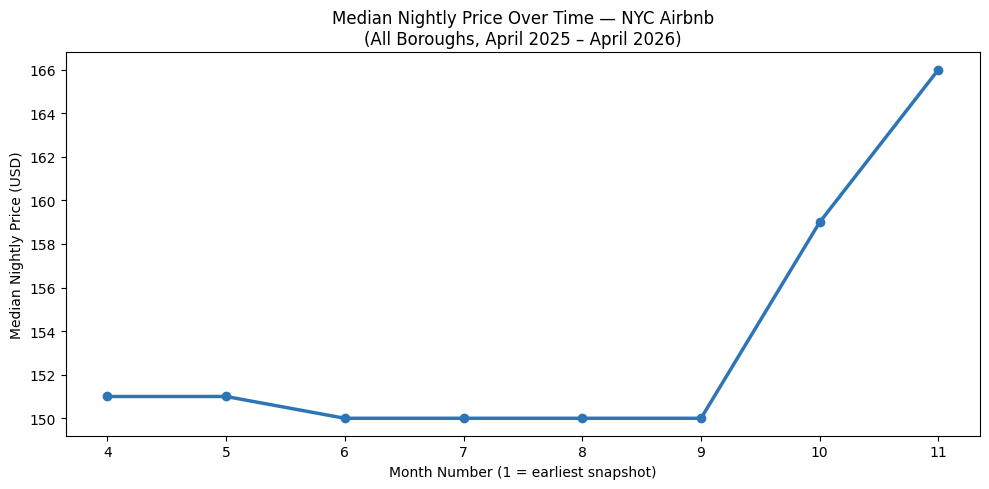

In [37]:
# Visualize the citywide price trend over 11 months
plt.figure(figsize=(10, 5))
plt.plot(price_trend['month_num'], price_trend['median_price'],
         marker='o', linewidth=2.5, color='#2E75B6')
plt.title('Median Nightly Price Over Time — NYC Airbnb\n(All Boroughs, April 2025 – April 2026)')
plt.xlabel('Month Number (1 = earliest snapshot)')
plt.ylabel('Median Nightly Price (USD)')
plt.xticks(price_trend['month_num'])
plt.tight_layout()
plt.show()

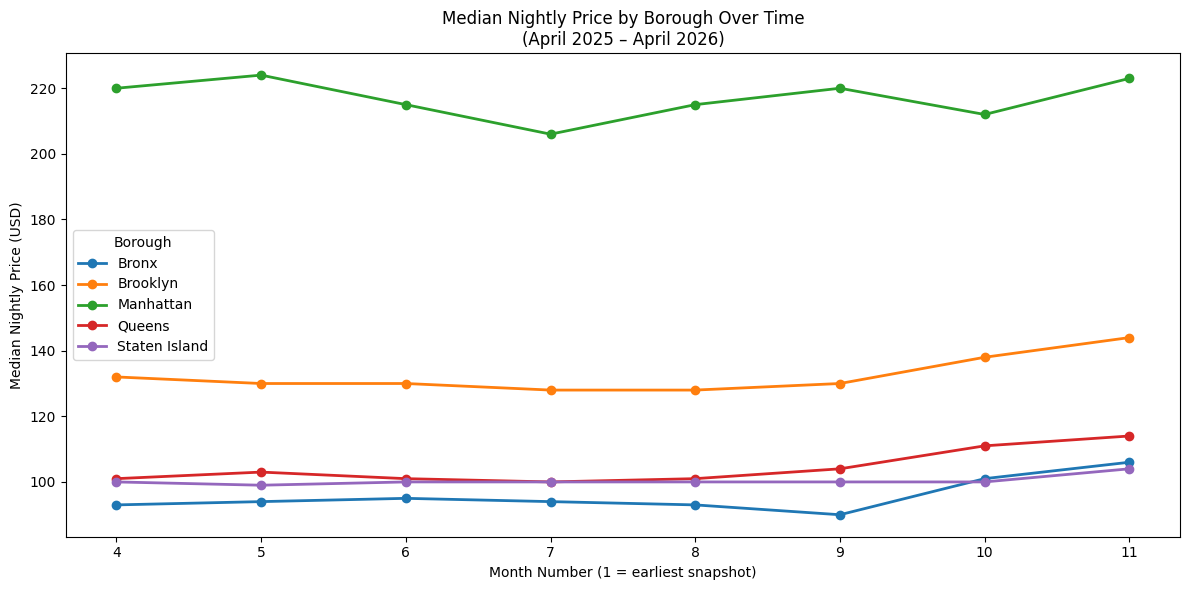

In [38]:
# Median price by month AND borough — is the trend uneven?
# This shows which boroughs are driving any price changes

price_by_borough = (
    listings_price_all
    .groupby(['month_num', 'neighbourhood_group'])['price']
    .median()
    .reset_index()
    .rename(columns={'price': 'median_price'})
)

plt.figure(figsize=(12, 6))
for borough in price_by_borough['neighbourhood_group'].unique():
    sub = price_by_borough[price_by_borough['neighbourhood_group'] == borough]
    plt.plot(sub['month_num'], sub['median_price'],
             marker='o', linewidth=2, label=borough)

plt.title('Median Nightly Price by Borough Over Time\n(April 2025 – April 2026)')
plt.xlabel('Month Number (1 = earliest snapshot)')
plt.ylabel('Median Nightly Price (USD)')
plt.legend(title='Borough')
plt.xticks(price_by_borough['month_num'].unique())
plt.tight_layout()
plt.show()

In [39]:
# Calculate the actual price change from first to last month
# Using f-strings from Class 1 to print clean output

first_month = listings_price_all['month_num'].min()
last_month  = listings_price_all['month_num'].max()

price_start = listings_price_all[listings_price_all['month_num'] == first_month]['price'].median()
price_end   = listings_price_all[listings_price_all['month_num'] == last_month]['price'].median()
pct_change  = (price_end - price_start) / price_start * 100

print(f'Median price (month {first_month}): ${price_start:.0f}/night')
print(f'Median price (month {last_month}):  ${price_end:.0f}/night')
print(f'Change over 11 months:            {pct_change:+.1f}%')
print()

# By borough
print('Price change by borough:')
for borough in sorted(listings_price_all['neighbourhood_group'].unique()):
    sub = listings_price_all[listings_price_all['neighbourhood_group'] == borough]
    p_start = sub[sub['month_num'] == first_month]['price'].median()
    p_end   = sub[sub['month_num'] == last_month]['price'].median()
    chg     = (p_end - p_start) / p_start * 100
    print(f'  {borough:<20} ${p_start:.0f} → ${p_end:.0f}  ({chg:+.1f}%)')

Median price (month 4): $151/night
Median price (month 11):  $166/night
Change over 11 months:            +9.9%

Price change by borough:
  Bronx                $93 → $106  (+14.0%)
  Brooklyn             $132 → $144  (+9.1%)
  Manhattan            $220 → $223  (+1.4%)
  Queens               $101 → $114  (+12.9%)
  Staten Island        $100 → $104  (+4.0%)


## H3 Finding: Prices Rose 9.9% Over 11 Months — Nearly 3x NYC's General 
Inflation Rate, Led by the Bronx and Queens

Citywide median nightly price held flat at $150-151 from months 4 through 9, 
then jumped sharply to $159 in month 10 and $166 in month 11. The full 
period change is +9.9% — concentrated almost entirely in the final two months, 
suggesting an accelerating trend rather than gradual drift.

The borough breakdown is where the most economically significant signal appears:

- Bronx:         $93 → $106/night  (+14.0%)
- Queens:        $101 → $114/night (+12.9%)
- Brooklyn:      $132 → $144/night (+9.1%)
- Staten Island: $100 → $104/night (+4.0%)
- Manhattan:     $220 → $223/night (+1.4%)

Note: months 1-3 are excluded from this analysis as no price data was 
available for those snapshots. The trend covers months 4-11 only.

---
## Section 8: Bonus Analysis A — Neighbourhood Opportunity Score

Beyond describing what is happening now, I can use the data to identify where market pressure may move next. I build a simple Opportunity Score for each neighbourhood by dividing the number of reviews by the number of active listings.

A high score means there is more visitor demand relative to available supply — these are the most underserved markets. I set a minimum of 10 listings per neighbourhood to make sure the score is meaningful.

**Limitation:** This score uses reviews as a demand proxy and listing count as a supply proxy. It does not account for listing quality, seasonality, or actual occupancy rates.

In [53]:
# Supply per neighbourhood from latest snapshot
supply_by_nbhd = (
    listings_snapshot
    .groupby(['neighbourhood', 'neighbourhood_group'])['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'listing_count'})
)

# Demand per neighbourhood from analysis-period reviews
demand_by_nbhd = (
    reviews_enriched
    .groupby('neighbourhood')['listing_id']
    .count()
    .reset_index()
    .rename(columns={'listing_id': 'review_count'})
)

# Median price per neighbourhood from latest snapshot
price_by_nbhd = (
    listings_price.groupby('neighbourhood')['price']
    .median()
    .reset_index()
    .rename(columns={'price': 'median_price'})
)

# Merge and calculate the score
opportunity = supply_by_nbhd.merge(demand_by_nbhd, on='neighbourhood', how='inner')
opportunity['opportunity_score'] = (
    opportunity['review_count'] / opportunity['listing_count']
).round(1)
opportunity = opportunity.merge(price_by_nbhd, on='neighbourhood', how='inner')
opportunity = opportunity[opportunity['listing_count'] >= 10]
opportunity = opportunity.sort_values('opportunity_score', ascending=False)

print('Top 15 Opportunity Neighbourhoods (10+ listings):')
print(opportunity[['neighbourhood','neighbourhood_group',
                   'listing_count','review_count',
                   'opportunity_score','median_price']].head(15).to_string(index=False))

Top 15 Opportunity Neighbourhoods (10+ listings):
      neighbourhood neighbourhood_group  listing_count  review_count  opportunity_score  median_price
      Fort Hamilton            Brooklyn            104          2839               27.3         117.0
   South Ozone Park              Queens             69          1227               17.8         168.0
      College Point              Queens             38           536               14.1         145.0
         Whitestone              Queens             18           228               12.7         124.0
            Clifton       Staten Island             12           138               11.5          90.0
  Claremont Village               Bronx             25           271               10.8         111.5
Springfield Gardens              Queens            130          1377               10.6         156.5
           Sea Gate            Brooklyn             17           179               10.5         140.0
         Bath Beach            B

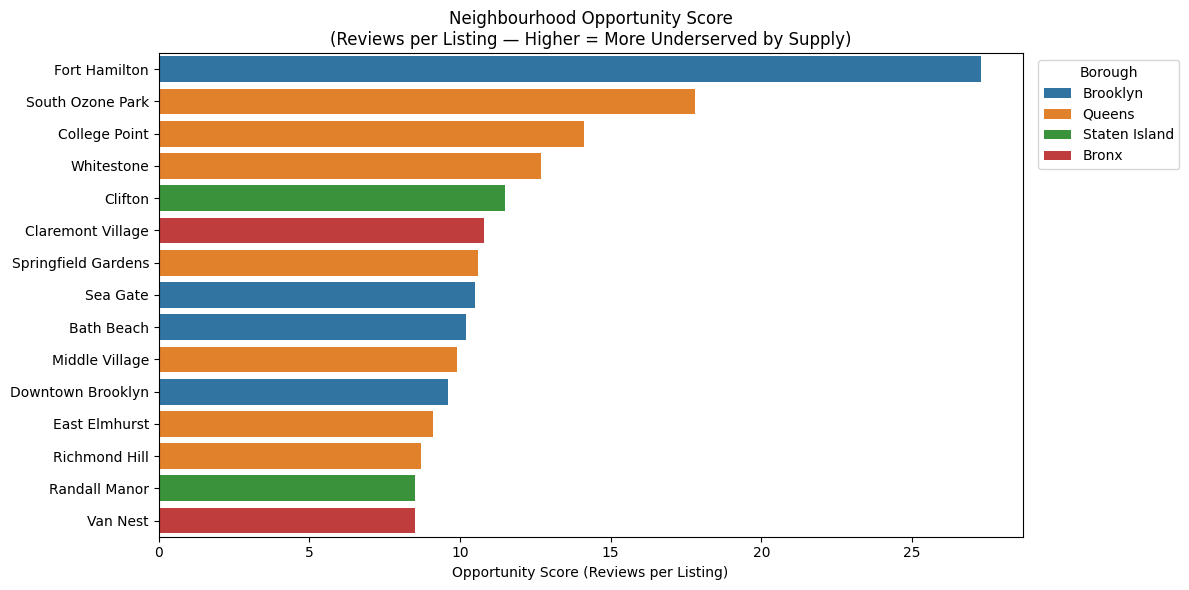

In [54]:
top_opp = opportunity.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_opp, x='opportunity_score', y='neighbourhood',
            hue='neighbourhood_group', dodge=False)
plt.title('Neighbourhood Opportunity Score\n(Reviews per Listing — Higher = More Underserved by Supply)')
plt.xlabel('Opportunity Score (Reviews per Listing)')
plt.ylabel('')
plt.legend(title='Borough', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Bonus Finding A:**

Several neighbourhoods show high review-to-listing ratios, meaning visitor demand appears to outpace current supply. These may be the markets where regulatory compliance requirements have reduced listing availability while visitor interest remains strong.

---
## Section 9: Bonus Analysis B — Demand vs Price Scatter

I normalize both the opportunity score and median price to a 0-100 scale so I can compare them fairly across all neighbourhoods. Neighbourhoods in the **top-left quadrant** have high demand relative to supply but lower prices, these may be the markets where prices have not yet caught up with visitor interest.

In [55]:
efficiency = opportunity.copy()

efficiency['demand_score'] = (
    (efficiency['opportunity_score'] - efficiency['opportunity_score'].min()) /
    (efficiency['opportunity_score'].max() - efficiency['opportunity_score'].min()) * 100
)
efficiency['price_score'] = (
    (efficiency['median_price'] - efficiency['median_price'].min()) /
    (efficiency['median_price'].max() - efficiency['median_price'].min()) * 100
)
efficiency['price_gap'] = efficiency['demand_score'] - efficiency['price_score']
top_gap = efficiency.sort_values('price_gap', ascending=False).head(15)

print('Neighbourhoods where demand score most outpaces price score:')
print(top_gap[['neighbourhood','neighbourhood_group',
               'opportunity_score','median_price','price_gap']].to_string(index=False))

Neighbourhoods where demand score most outpaces price score:
      neighbourhood neighbourhood_group  opportunity_score  median_price  price_gap
      Fort Hamilton            Brooklyn               27.3         117.0  87.110187
   South Ozone Park              Queens               17.8         168.0  41.322091
            Clifton       Staten Island               11.5          90.0  34.204974
      College Point              Queens               14.1         145.0  32.400092
         Whitestone              Queens               12.7         124.0  31.580812
  Claremont Village               Bronx               10.8         111.5  27.142527
      Richmond Hill              Queens                8.7         100.0  21.755602
       Clason Point               Bronx                7.4          84.5  20.163240
           Sea Gate            Brooklyn               10.5         140.0  20.106260
     Middle Village              Queens                9.9         132.0  19.547240
      East Elmh

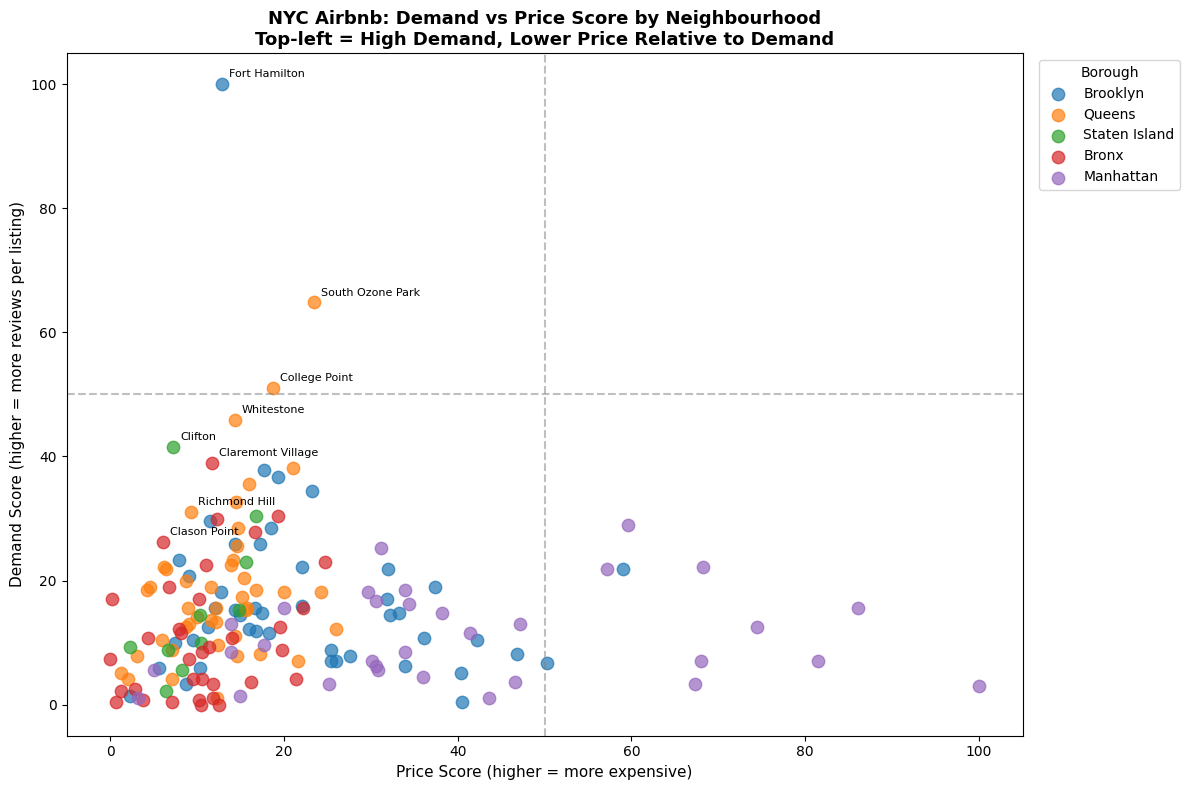

In [56]:
fig, ax = plt.subplots(figsize=(12, 8))

for borough in efficiency['neighbourhood_group'].unique():
    sub = efficiency[efficiency['neighbourhood_group'] == borough]
    ax.scatter(sub['price_score'], sub['demand_score'],
               label=borough, alpha=0.7, s=80)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

for _, row in top_gap.head(8).iterrows():
    ax.annotate(row['neighbourhood'],
                xy=(row['price_score'], row['demand_score']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Price Score (higher = more expensive)', fontsize=11)
ax.set_ylabel('Demand Score (higher = more reviews per listing)', fontsize=11)
ax.set_title('NYC Airbnb: Demand vs Price Score by Neighbourhood\nTop-left = High Demand, Lower Price Relative to Demand',
             fontsize=13, fontweight='bold')
ax.legend(title='Borough', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Bonus Finding B:**

Several Bronx and Queens neighbourhoods appear in the top-left quadrant, relatively high demand per listing but lower prices compared to Manhattan and parts of Brooklyn. Manhattan neighbourhoods cluster toward the bottom-right, which is consistent with high prices and proportionally lower demand per listing as visitors look elsewhere.

This pattern is worth watching. The Bronx and Queens may be at a similar point to where Brooklyn was several years ago, growing visitor interest but prices that have not yet adjusted. Whether this leads to the same trajectory as Brooklyn would depend on many factors beyond what this dataset can confirm.